<a href="https://colab.research.google.com/github/hachieu111/Machine-Learning_Canh-Bao-Am-Thanh/blob/main/Canhbaoamthanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow tensorflow_hub librosa pyngrok flask

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Nhãn thực tế (Ground Truth): Bạn biết chắc chắn file đó là gì
# 1: Nguy hiểm, 0: An toàn
y_true = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# 2. Nhãn dự đoán (Predicted): Những gì AI trả về sau khi bạn test
y_pred = [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]

# 3. Xác suất dự đoán (dành cho AUC-ROC): Độ tự tin (confidence) của AI
y_probs = [0.9, 0.85, 0.4, 0.95, 0.8, 0.7, 0.3, 0.88, 0.92, 0.81, 0.1, 0.2, 0.6, 0.15, 0.05, 0.1, 0.2, 0.1, 0.3, 0.55]

In [3]:
# In báo cáo tổng quát
print("=== BÁO CÁO CHỈ SỐ ĐÁNH GIÁ HỆ THỐNG ===")
report = classification_report(y_true, y_pred, target_names=['An toàn', 'Nguy hiểm'])
print(report)

# Tính AUC-ROC
auc = roc_auc_score(y_true, y_probs)
print(f"Chỉ số AUC-ROC: {auc:.2f}")

=== BÁO CÁO CHỈ SỐ ĐÁNH GIÁ HỆ THỐNG ===
              precision    recall  f1-score   support

     An toàn       0.80      0.80      0.80        10
   Nguy hiểm       0.80      0.80      0.80        10

    accuracy                           0.80        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.80      0.80      0.80        20

Chỉ số AUC-ROC: 0.96


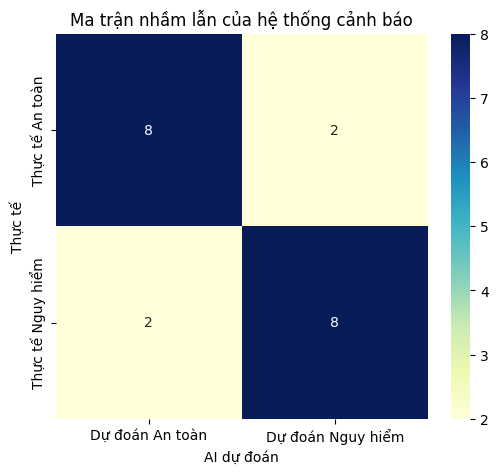

In [4]:
# Vẽ Heatmap cho Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Dự đoán An toàn', 'Dự đoán Nguy hiểm'],
            yticklabels=['Thực tế An toàn', 'Thực tế Nguy hiểm'])
plt.title('Ma trận nhầm lẫn của hệ thống cảnh báo')
plt.ylabel('Thực tế')
plt.xlabel('AI dự đoán')
plt.show()

In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import librosa
import requests

# 1. Cấu hình Telegram
TELEGRAM_TOKEN = '8643484736:AAHJLWQgnuDuNXOaWzAP9pFy-7MSuJIo31o'
CHAT_ID = '6496305290'

def send_telegram_alert(message):
    url = f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage"
    payload = {"chat_id": CHAT_ID, "text": message}
    try:
        requests.post(url, json=payload)
        print("Đã gửi cảnh báo qua Telegram!")
    except Exception as e:
        print("Lỗi gửi Telegram:", e)

# 2. Tải mô hình YAMNet từ TensorFlow Hub
print("Đang tải mô hình YAMNet...")
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

# Tải danh sách tên các loại âm thanh (Class maps)
class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
class_names = [line.strip().split(',')[2] for line in open(class_map_path).readlines()[1:]]
print("Tải mô hình thành công!")

Đang tải mô hình YAMNet...
Tải mô hình thành công!


In [6]:
# Các loại âm thanh được coi là nguy hiểm (Bạn có thể thêm bớt tùy ý)
DANGEROUS_SOUNDS = [
    'Glass', 'Siren', 'Gunshot, gunfire', 'Scream', 'Explosion',
    'Helicopter', 'Vehicle', 'Mechanisms', 'Clock'
]

def analyze_audio(file_path):
    # Đọc file âm thanh và chuyển về tần số chuẩn của YAMNet (16kHz)
    wav_data, sr = librosa.load(file_path, sr=16000)

    # YAMNet yêu cầu mảng 1D
    if len(wav_data.shape) > 1:
        wav_data = np.mean(wav_data, axis=1)

    # Chạy mô hình dự đoán
    scores, embeddings, spectrogram = yamnet_model(wav_data)

    # Lấy ra điểm số cao nhất cho toàn bộ đoạn âm thanh
    mean_scores = np.mean(scores, axis=0)
    top_class_index = np.argmax(mean_scores)
    top_class_name = class_names[top_class_index]
    confidence = mean_scores[top_class_index] * 100

    print(f"Nhận diện: {top_class_name} ({confidence:.2f}%)")

    # Kiểm tra xem âm thanh này có nằm trong danh sách nguy hiểm không
    for danger in DANGEROUS_SOUNDS:
        if danger.lower() in top_class_name.lower() and confidence > 20.0:
            msg = f"⚠️ CẢNH BÁO NGUY HIỂM: Phát hiện {top_class_name} với độ tin cậy {confidence:.2f}%!"
            send_telegram_alert(msg)
            return True

    return False

In [7]:
from flask import Flask, request, jsonify
from pyngrok import ngrok
import os

app = Flask(__name__)

# Điền ngrok authtoken của bạn vào đây
ngrok.set_auth_token("3Ca6nlDyfXlukKYoYTTu1Oz9lQ6_4Cij4z1Q2L6oQh6WDse7t")

@app.route('/upload', methods=['POST'])
def upload_audio():
    if 'file' not in request.files:
        return jsonify({"error": "Không tìm thấy file"}), 400

    file = request.files['file']
    file_path = "temp_audio.wav"
    file.save(file_path)

    # Gọi hàm AI phân tích
    is_danger = analyze_audio(file_path)

    # Xóa file tạm
    os.remove(file_path)

    return jsonify({"status": "success", "danger_detected": is_danger}), 200

# Khởi chạy ngrok và Flask
public_url = ngrok.connect(5000)
print(f"🚀 API CHÍNH THỨC CỦA BẠN ĐÂY: {public_url}/upload")

# Chạy server
app.run()

🚀 API CHÍNH THỨC CỦA BẠN ĐÂY: NgrokTunnel: "https://gallantly-sway-trapdoor.ngrok-free.dev" -> "http://localhost:5000"/upload
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


Nhận diện: Clock (38.42%)


INFO:werkzeug:127.0.0.1 - - [28/May/2026 07:12:57] "POST /upload HTTP/1.1" 200 -


Đã gửi cảnh báo qua Telegram!
Nhận diện: Clock (38.42%)


...

Đã gửi cảnh báo qua Telegram!
Nhận diện: Vehicle (64.52%)


INFO:werkzeug:127.0.0.1 - - [28/May/2026 07:29:21] "POST /upload HTTP/1.1" 200 -


Đã gửi cảnh báo qua Telegram!
Nhận diện: Vehicle (64.52%)


INFO:werkzeug:127.0.0.1 - - [28/May/2026 07:31:13] "POST /upload HTTP/1.1" 200 -


Đã gửi cảnh báo qua Telegram!


In [8]:
!pip install -q pyngrok flask tensorflow_hub librosa